In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Masking,Dropout,BatchNormalization,GRU,Bidirectional,Attention, Concatenate, Input,Reshape
from sklearn.preprocessing import LabelEncoder
from gensim.models import Word2Vec
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from imblearn.under_sampling import RandomUnderSampler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model


In [14]:
train_data  = pd.read_csv('resources/train.csv')
valid_data = pd.read_csv('resources/val.csv')
test_data = pd.read_csv('resources/test_nolabel.csv')

In [15]:
x_train = train_data['text']
y_train = train_data['label']

x_valid = valid_data['text']
y_valid = valid_data['label']

x_test = test_data['text']

In [16]:
train_data.head()

,id,label,text
0,8901,5,Bennett 's naturalistic performance speaks vol...
1,2506,5,"Shot in rich , shadowy black-and-white , Devil..."
2,2381,5,"More than their unique residences , Home Movie..."
3,1262,3,The movie should be credited with remembering ...
4,2542,4,Audiences are advised to sit near the back and...


In [17]:
MAX_VOCAB_SIZE = 15197
MAX_SEQUENCE_LENGTH = 54
EMBEDDING_DIM = 100  
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train)
word_index = tokenizer.word_index

In [18]:
SOS_token, EOS_token = '<SOS>', '<EOS>'

# Add SOS and EOS tokens to tokenizer's word index if not present
for token in [SOS_token, EOS_token]:
    tokenizer.word_index.setdefault(token, len(tokenizer.word_index) + 1)

# Convert text data to sequences with SOS and EOS tokens
def add_tokens_and_convert(texts):
    return [[tokenizer.word_index[SOS_token]] + seq + [tokenizer.word_index[EOS_token]]
            for seq in tokenizer.texts_to_sequences(texts)]

sequences_train, sequences_valid, sequences_test = map(add_tokens_and_convert, [x_train, x_valid, x_test])

# Determine max sequence length
MAX_SEQUENCE_LENGTH = max(map(len, sequences_train + sequences_valid + sequences_test))

# Pad sequences to uniform length
x_train, x_valid, x_test = map(lambda seqs: pad_sequences(seqs, maxlen=MAX_SEQUENCE_LENGTH, padding='post'),
                               [sequences_train, sequences_valid, sequences_test])

In [19]:
MAX_VOCAB_SIZE = len(tokenizer.word_index) + 1  # +1 to account for padding token

print(f"Maximum vocabulary size: {MAX_VOCAB_SIZE}")

Maximum vocabulary size: 15197


In [20]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_valid = encoder.transform(y_valid)

In [21]:
w2v_model = Word2Vec(sentences=[text.split() for text in train_data['text']], vector_size=EMBEDDING_DIM, window=5, min_count=1, workers=4)

In [22]:
embedding_matrix = np.zeros((MAX_VOCAB_SIZE+2, EMBEDDING_DIM))
for word, i in word_index.items():
    if i < MAX_VOCAB_SIZE and word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [23]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

In [27]:
# Define model
model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE + 2, output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix], input_length=MAX_SEQUENCE_LENGTH,
              trainable=True, embeddings_regularizer=l2(0.01)),
    
    Masking(mask_value=0.0),
    
    Bidirectional(GRU(178, activation='tanh', dropout=0.5, recurrent_dropout=0.5,
                      kernel_regularizer=l2(1e-4), recurrent_regularizer=l2(0.01))),
    
    Dropout(0.5),
    BatchNormalization(),
    
    Dense(5, activation='softmax', kernel_regularizer=l2(0.01))
])

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
]

# Train model
history = model.fit(x_train, y_train, epochs=32, batch_size=32,
                    validation_data=(x_valid, y_valid),
                    class_weight=class_weight_dict,
                    callbacks=callbacks)


Epoch 1/32


C:\Users\Admin\anaconda3\envs\new\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


260/260 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step - accuracy: 0.2090 - loss: 85.9227 - val_accuracy: 0.1890 - val_loss: 49.0110 - learning_rate: 0.0010
Epoch 2/32
260/260 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - accuracy: 0.2063 - loss: 43.0566 - val_accuracy: 0.2615 - val_loss: 28.7000 - learning_rate: 0.0010
Epoch 3/32
260/260 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.2189 - loss: 25.6698 - val_accuracy: 0.2188 - val_loss: 18.0560 - learning_rate: 0.0010
Epoch 4/32
260/260 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.2232 - loss: 16.3345 - val_accuracy: 0.2047 - val_loss: 11.9337 - learning_rate: 0.0010
Epoch 5/32
260/260 ━━━━━━━━━━━━━━━━━━━━ 23s 88ms/step - accuracy: 0.2336 - loss: 10.8980 - val_accuracy: 0.2351 - val_loss: 8.2290 - learning_rate: 0.0010
Epoch 6/32
260/260 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.2497 - loss: 7.5984 - val_accuracy: 0.2745 - val_loss: 5.9426 - learning_rate: 0.0010
Epoch 7/32
260/260 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.2986 - lo

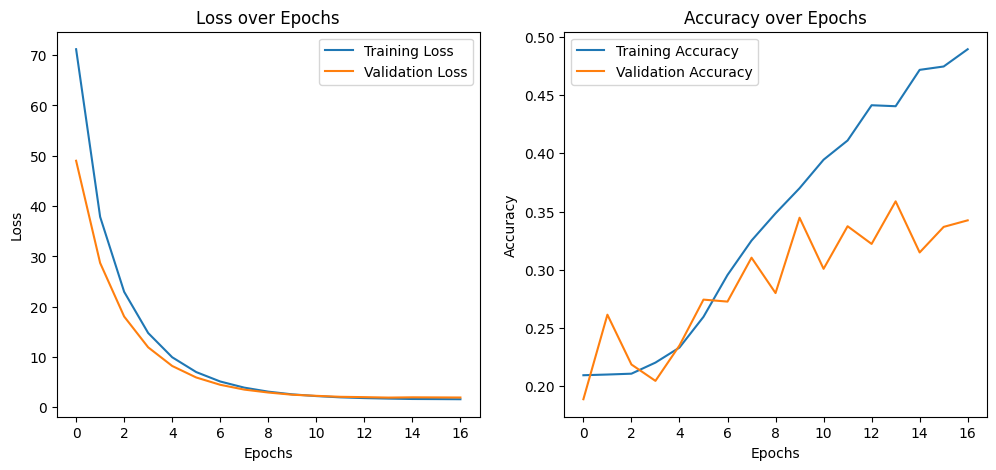

In [28]:
import matplotlib.pyplot as plt

# Extract loss and accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()